In [1]:
import pandas as pd

# Load the datasets into pandas DataFrames
df_data = pd.read_csv('IDS_ALLCountries_Data.csv', encoding='latin1')
df_country_meta = pd.read_csv('IDS_CountryMetaData.csv', encoding='latin1')
df_series_meta = pd.read_csv('IDS_SeriesMetaData.csv', encoding='latin1')
df_footnote_meta = pd.read_csv('IDS_FootNoteMetaData.csv', encoding='latin1')
df_country_series = pd.read_csv('Country-Series - Metadata.csv', encoding='latin1')

In [2]:
# Check null counts and percentages for each dataset
def check_nulls(df, name):
    null_counts = df.isnull().sum()
    null_pct = (df.isnull().sum() / len(df)) * 100
    summary = pd.DataFrame({'Missing Values': null_counts, 'Percentage (%)': null_pct})
    print(f"--- Missing Values: {name} ---")
    display(summary[summary['Missing Values'] > 0])

check_nulls(df_data, 'Main Financial Data')
check_nulls(df_country_meta, 'Country Metadata')
check_nulls(df_series_meta, 'Series Metadata')

--- Missing Values: Main Financial Data ---


,Missing Values,Percentage (%)
Country Name,3,0.004763
Country Code,5,0.007939
Counterpart-Area Name,5,0.007939
Counterpart-Area Code,5,0.007939
Series Name,5,0.007939
Series Code,5,0.007939
2000,13493,21.423241
2001,13549,21.512154
2002,13721,21.785244
2003,13982,22.199641


--- Missing Values: Country Metadata ---


,Missing Values,Percentage (%)
Income Group,15,11.194030
Region,14,10.447761
Lending category,14,10.447761
Other groups,94,70.149254
Currency Unit,14,10.447761
Latest population census,16,11.940299
Latest household survey,14,10.447761
Special Notes,74,55.223881
National accounts base year,14,10.447761
National accounts reference year,95,70.895522


--- Missing Values: Series Metadata ---


,Missing Values,Percentage (%)
License Type,572,99.651568
Short definition,2,0.348432
Dataset,1,0.174216
Limitations and exceptions,573,99.825784
General comments,566,98.606272


In [3]:
# Drop World Bank metadata from the main financial table
df_data_clean = df_data.dropna(subset=['Country Code', 'Series Code']).copy()

# Verify cleaned main data dimensions
print(f"Original shape: {df_data.shape}")
print(f"Cleaned shape:  {df_data_clean.shape}")

Original shape: (62983, 39)
Cleaned shape:  (62978, 39)


In [4]:
# Define identifier columns and historical years (2000 to 2026)
id_cols = ['Country Name', 'Country Code','Counterpart-Area Name', 'Counterpart-Area Code','Series Name', 'Series Code']
historical_years = [str(year) for year in range(2000, 2027)]

# Reshape from wide to long format
df_long = pd.melt(
    df_data_clean,
    id_vars=id_cols,
    value_vars=historical_years,
    var_name='Year',
    value_name='Value'
)

# Standardize data types
df_long['Year'] = df_long['Year'].astype(int)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

# Remove rows where Value is NaN
df_long_clean = df_long.dropna(subset=['Value']).reset_index(drop=True)

# Review shape and sample rows
print(f"Reshaped & cleaned dataset shape: {df_long_clean.shape}")
display(df_long_clean.head())

Reshaped & cleaned dataset shape: (1272550, 8)


,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,Year,Value
0,Albania,ALB,World,WLD,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,10.5454
1,Albania,ALB,World,WLD,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,10.5454
2,Albania,ALB,World,WLD,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,0.0000
3,Albania,ALB,World,WLD,Average grant element on new external debt com...,DT.GRE.DPPG,2000,25.7609
4,Albania,ALB,World,WLD,Average grant element on new external debt com...,DT.GRE.OFFT,2000,25.7609


In [5]:
# Remove duplicate records
initial_rows = len(df_long_clean)
df_cleaned = df_long_clean.drop_duplicates().copy()
print(f"Duplicates removed: {initial_rows - len(df_cleaned)}")

# Perform data type conversion
df_cleaned['Year'] = df_cleaned['Year'].astype('int16')
df_cleaned['Value'] = pd.to_numeric(df_cleaned['Value'], errors='coerce').astype('float64')

# Standardize text columns (strip accidental leading/trailing whitespace)
text_columns = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
for col in text_columns:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip()

# Filter relevant columns
relevant_cols = ['Country Name', 'Country Code', 'Series Name', 'Series Code', 'Year', 'Value']
df_final = df_cleaned[relevant_cols].reset_index(drop=True)

# Verify the standardized dataset
print(f"\nFinal cleaned dataset shape: {df_final.shape}")
display(df_final.info())
display(df_final.head())

Duplicates removed: 0

Final cleaned dataset shape: (1272550, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272550 entries, 0 to 1272549
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Country Name  1272550 non-null  object 
 1   Country Code  1272550 non-null  object 
 2   Series Name   1272550 non-null  object 
 3   Series Code   1272550 non-null  object 
 4   Year          1272550 non-null  int16  
 5   Value         1272550 non-null  float64
dtypes: float64(1), int16(1), object(4)
memory usage: 51.0+ MB


None

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Albania,ALB,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,10.5454
1,Albania,ALB,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,10.5454
2,Albania,ALB,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,0.0000
3,Albania,ALB,Average grant element on new external debt com...,DT.GRE.DPPG,2000,25.7609
4,Albania,ALB,Average grant element on new external debt com...,DT.GRE.OFFT,2000,25.7609


# EDA

In [6]:
import pandas as pd
import numpy as np

# Merge Cleaned Long Dataset with Country Metadata
df_eda = df_final.merge(
    df_country_meta[['Code', 'Region', 'Income Group']],
    left_on='Country Code',
    right_on='Code',
    how='left'
)

# Filter for individual countries
df_countries = df_eda[df_eda['Region'].notnull()].copy()
df_ppg_2026 = df_countries[(df_countries['Series Code'] == 'DT.TDS.DPPG.CD') & (df_countries['Year'] == 2026)].copy()


# OUNTRY-WISE DEBT DISTRIBUTION (2026 PROJECTIONS)

print("COUNTRY-WISE DEBT DISTRIBUTION")

reg_dist = df_ppg_2026.groupby('Region')['Value'].agg(
    Country_Count='count',
    Total_PPG_Debt_Service_Billion=lambda x: round(x.sum() / 1e9, 2),
    Mean_Billion=lambda x: round(x.mean() / 1e9, 2),
    Median_Billion=lambda x: round(x.median() / 1e9, 2)
).sort_values('Total_PPG_Debt_Service_Billion', ascending=False)
display(reg_dist)

inc_dist = df_ppg_2026.groupby('Income Group')['Value'].agg(
    Total_PPG_Debt_Service_Billion=lambda x: round(x.sum() / 1e9, 2),
    Percentage_Share=lambda x: round((x.sum() / df_ppg_2026['Value'].sum()) * 100, 1)
).sort_values('Total_PPG_Debt_Service_Billion', ascending=False)

print("\nIncome Tier Distribution:")
display(inc_dist)

COUNTRY-WISE DEBT DISTRIBUTION


,Country_Count,Total_PPG_Debt_Service_Billion,Mean_Billion,Median_Billion
Region,,,,
East Asia & Pacific,16,112.94,7.06,0.92
Latin America & Caribbean,22,110.31,5.01,1.25
Sub-Saharan Africa,45,62.63,1.39,0.48
Europe & Central Asia,18,60.87,3.38,1.09
Middle East & North Africa,13,57.30,4.41,2.61
South Asia,6,53.27,8.88,2.74



Income Tier Distribution:


,Total_PPG_Debt_Service_Billion,Percentage_Share
Income Group,,
Upper middle income,277.02,60.6
Lower middle income,169.78,37.1
Low income,7.42,1.6
High income,0.24,0.1


In [7]:
# TOP & LOWEST COUNTRIES WITH PROJECTED DEBT SERVICE (2026)

print("TOP & LOWEST COUNTRIES WITH PROJECTED DEBT SERVICE (2026)")

# Total Debt Service across all sectors (Public + Private)
df_tot_2026 = df_countries[(df_countries['Series Code'] == 'DT.TDS.DECT.CD') & (df_countries['Year'] == 2026)][['Country Name', 'Value']].rename(columns={'Value': 'Total_Debt_Service_All_Sectors'})

top_10 = df_ppg_2026.sort_values('Value', ascending=False).head(10).merge(df_tot_2026, on='Country Name', how='left')
top_10_table = pd.DataFrame({
    'Country Name': top_10['Country Name'],
    'Region': top_10['Region'],
    'Income Group': top_10['Income Group'],
    'PPG Debt Service ($B)': (top_10['Value'] / 1e9).round(2),
    'Total Debt Service (All Sectors) ($B)': (top_10['Total_Debt_Service_All_Sectors'] / 1e9).round(2)
})
print("Top 10 Highest Public Debt Service (PPG) in 2026:")
display(top_10_table)

bottom_10 = df_ppg_2026.sort_values('Value', ascending=True).head(10)
bottom_10_table = pd.DataFrame({
    'Country Name': bottom_10['Country Name'],
    'Region': bottom_10['Region'],
    'Income Group': bottom_10['Income Group'],
    'PPG Debt Service ($M)': (bottom_10['Value'] / 1e6).round(2)
})
print("\nTop 10 Lowest Public Debt Service (PPG) in 2026:")
display(bottom_10_table)

TOP & LOWEST COUNTRIES WITH PROJECTED DEBT SERVICE (2026)
Top 10 Highest Public Debt Service (PPG) in 2026:


,Country Name,Region,Income Group,PPG Debt Service ($B),Total Debt Service (All Sectors) ($B)
0,China,East Asia & Pacific,Upper middle income,69.42,167.00
1,Mexico,Latin America & Caribbean,Upper middle income,39.55,83.27
2,India,South Asia,Lower middle income,39.53,80.66
3,Turkiye,Europe & Central Asia,Upper middle income,28.40,65.61
4,Indonesia,East Asia & Pacific,Upper middle income,24.20,46.95
5,Brazil,Latin America & Caribbean,Upper middle income,22.34,115.00
6,"Egypt, Arab Rep.",Middle East & North Africa,Lower middle income,21.98,26.16
7,Pakistan,Middle East & North Africa,Lower middle income,15.60,20.88
8,Colombia,Latin America & Caribbean,Upper middle income,11.80,26.54
9,Argentina,Latin America & Caribbean,Upper middle income,11.44,22.26



Top 10 Lowest Public Debt Service (PPG) in 2026:


,Country Name,Region,Income Group,PPG Debt Service ($M)
1269983,"Somalia, Fed. Rep.",Sub-Saharan Africa,Low income,9.60
1269926,Solomon Islands,East Asia & Pacific,Lower middle income,10.48
1271291,Tonga,East Asia & Pacific,Upper middle income,20.41
1269584,Sao Tome and Principe,Sub-Saharan Africa,Lower middle income,22.40
1270837,Syrian Arab Republic,Middle East & North Africa,Low income,23.58
1272158,Vanuatu,East Asia & Pacific,Lower middle income,25.49
1269528,Samoa,East Asia & Pacific,Upper middle income,28.52
1264471,Haiti,Latin America & Caribbean,Lower middle income,29.11
1261651,Central African Republic,Sub-Saharan Africa,Low income,31.62
1262461,Dominica,Latin America & Caribbean,Upper middle income,32.74


In [8]:
# DEBT INDICATORS AND THEIR IMPACT (2026 STRUCTURE)

print("DEBT INDICATORS AND THEIR IMPACT (2026 STRUCTURE)")

ppg_amt = df_countries[(df_countries['Series Code'] == 'DT.AMT.DPPG.CD') & (df_countries['Year'] == 2026)]['Value'].sum() / 1e9
ppg_int = df_countries[(df_countries['Series Code'] == 'DT.INT.DPPG.CD') & (df_countries['Year'] == 2026)]['Value'].sum() / 1e9
ppg_tot = df_countries[(df_countries['Series Code'] == 'DT.TDS.DPPG.CD') & (df_countries['Year'] == 2026)]['Value'].sum() / 1e9

impact_table = pd.DataFrame({
    'Indicator Component': ['Principal Repayments (Amortization)', 'Interest Payments', 'Total PPG Debt Service'],
    'Amount ($ Billions)': [round(ppg_amt, 2), round(ppg_int, 2), round(ppg_tot, 2)],
    'Share (%)': [round((ppg_amt / ppg_tot) * 100, 1), round((ppg_int / ppg_tot) * 100, 1), 100.0]
})
display(impact_table)

DEBT INDICATORS AND THEIR IMPACT (2026 STRUCTURE)


,Indicator Component,Amount ($ Billions),Share (%)
0,Principal Repayments (Amortization),309.41,67.7
1,Interest Payments,147.92,32.3
2,Total PPG Debt Service,457.33,100.0


In [9]:
# PATTERNS, TRENDS, AND RELATIONSHIPS (2000–2026)

print("PATTERNS, TRENDS, AND RELATIONSHIPS (2000–2026)")

trend_table = df_countries[df_countries['Series Code'] == 'DT.TDS.DPPG.CD'].groupby('Year')['Value'].sum().reset_index()
trend_table['PPG Debt Service ($B)'] = (trend_table['Value'] / 1e9).round(2)

top5_val = df_ppg_2026.nlargest(5, 'Value')['Value'].sum()
top5_share = (top5_val / df_ppg_2026['Value'].sum()) * 100

print(f"\nTop 5 Debtor Nations Concentration Ratio (2026): {top5_share:.1f}% of total obligations")
print("\nKey Milestone Years (2000-2026):")
display(trend_table[trend_table['Year'].isin([2000, 2005, 2010, 2015, 2020, 2024, 2025, 2026])].reset_index(drop=True))

PATTERNS, TRENDS, AND RELATIONSHIPS (2000–2026)

Top 5 Debtor Nations Concentration Ratio (2026): 44.0% of total obligations

Key Milestone Years (2000-2026):


,Year,Value,PPG Debt Service ($B)
0,2000,1.514950e+11,151.50
1,2005,1.590384e+11,159.04
2,2010,1.482428e+11,148.24
3,2015,2.506346e+11,250.63
4,2020,3.399307e+11,339.93
5,2024,4.716440e+11,471.64
6,2025,4.846134e+11,484.61
7,2026,4.573331e+11,457.33


In [10]:
# STATISTICAL SUMMARY (2026 PPG DEBT SERVICE)

print("STATISTICAL SUMMARY (2026 PPG DEBT SERVICE)")

stats = df_ppg_2026['Value'].describe()
min_country = df_ppg_2026.loc[df_ppg_2026['Value'].idxmin()]['Country Name']
max_country = df_ppg_2026.loc[df_ppg_2026['Value'].idxmax()]['Country Name']

stats_table = pd.DataFrame({
    'Metric': [
        'Count', 'Mean ($B)', 'Std Dev ($B)',
        'Minimum ($M)', '25th Percentile Q1 ($M)',
        'Median ($B)', '75th Percentile Q3 ($B)', 'Maximum ($B)'
    ],
    'Value': [
        f"{int(stats['count'])} countries",
        f"${stats['mean']/1e9:.2f} B",
        f"${stats['std']/1e9:.2f} B",
        f"${stats['min']/1e6:.2f} M ({min_country})",
        f"${stats['25%']/1e6:.2f} M",
        f"${stats['50%']/1e9:.2f} B",
        f"${stats['75%']/1e9:.2f} B",
        f"${stats['max']/1e9:.2f} B ({max_country})"
    ]
})
display(stats_table)

STATISTICAL SUMMARY (2026 PPG DEBT SERVICE)


,Metric,Value
0,Count,120 countries
1,Mean ($B),$3.81 B
2,Std Dev ($B),$9.10 B
3,Minimum ($M),"$9.60 M (Somalia, Fed. Rep.)"
4,25th Percentile Q1 ($M),$157.39 M
5,Median ($B),$0.72 B
6,75th Percentile Q3 ($B),$3.58 B
7,Maximum ($B),$69.42 B (China)


# Visulatization

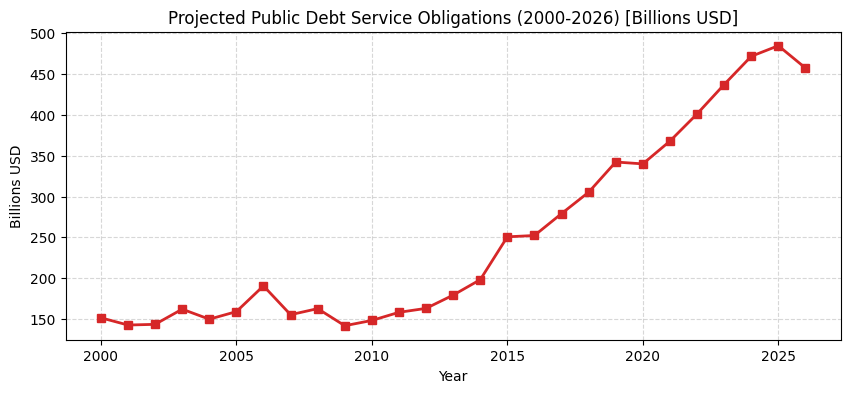

/tmp/ipykernel_1168/1341768861.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_2026, x=(top_10_2026['Value'] / 1e9), y='Country Name', palette='Reds_r')


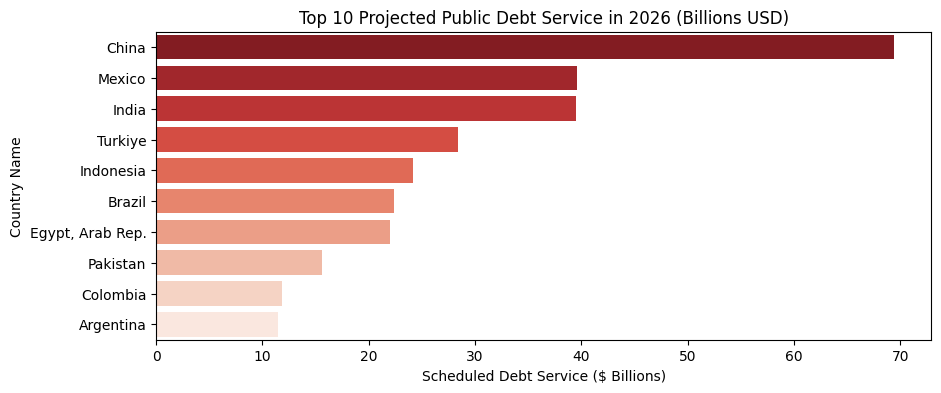

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Public and Publicly Guaranteed Debt Service (DT.TDS.DPPG.CD)
df_eda_2026 = df_final[df_final['Series Code'] == 'DT.TDS.DPPG.CD'].merge(
    df_country_meta[['Code', 'Region', 'Income Group']],
    left_on='Country Code', right_on='Code', how='left'
)
df_eda_2026 = df_eda_2026[df_eda_2026['Region'].notnull()]

# Plot Debt Service Trend (2000-2026)
plt.figure(figsize=(10, 4))
trend_service = df_eda_2026.groupby('Year')['Value'].sum() / 1e9
plt.plot(trend_service.index, trend_service.values, marker='s', color='#d62728', linewidth=2)
plt.title('Projected Public Debt Service Obligations (2000-2026) [Billions USD]')
plt.xlabel('Year')
plt.ylabel('Billions USD')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Top 10 Debt Service Commitments in 2026
top_10_2026 = df_eda_2026[df_eda_2026['Year'] == 2026].nlargest(10, 'Value')
plt.figure(figsize=(10, 4))
sns.barplot(data=top_10_2026, x=(top_10_2026['Value'] / 1e9), y='Country Name', palette='Reds_r')
plt.title('Top 10 Projected Public Debt Service in 2026 (Billions USD)')
plt.xlabel('Scheduled Debt Service ($ Billions)')
plt.show()

In [12]:
from google.colab import files
import pandas as pd

# Prepare dim_countries table
df_dim_countries = df_country_meta[['Code', 'Short Name', 'Region', 'Income Group', 'Currency Unit']].copy()
df_dim_countries.columns = ['country_code', 'country_name', 'region', 'income_group', 'currency_unit']
df_dim_countries = df_dim_countries.drop_duplicates(subset=['country_code']).dropna(subset=['country_code'])

# Prepare dim_indicators table
df_dim_indicators = df_series_meta[['Code', 'Indicator Name', 'Topic', 'Source']].copy()
df_dim_indicators.columns = ['series_code', 'series_name', 'topic', 'source']
df_dim_indicators = df_dim_indicators.drop_duplicates(subset=['series_code']).dropna(subset=['series_code'])

# Prepare fact_debt_data table
valid_countries = set(df_dim_countries['country_code'])
valid_series = set(df_dim_indicators['series_code'])

df_fact_debt = df_final[
    (df_final['Country Code'].isin(valid_countries)) &
    (df_final['Series Code'].isin(valid_series))
][['Country Code', 'Series Code', 'Year', 'Value']].copy()
df_fact_debt.columns = ['country_code', 'series_code', 'year', 'debt_value']

# Save to CSV
df_dim_countries.to_csv('dim_countries.csv', index=False)
df_dim_indicators.to_csv('dim_indicators.csv', index=False)
df_fact_debt.to_csv('fact_debt_data.csv', index=False)

# Trigger browser downloads
files.download('dim_countries.csv')
files.download('dim_indicators.csv')
files.download('fact_debt_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>